In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv('androfuzz-mlc/balanced_augmented_dataset.csv')

print(df.shape)

(2400, 12)


In [34]:
"""


# Load parquet files
benign_df = pd.read_csv("processedData/benign.csv")
mal_df = pd.read_csv("processedData/malware_binary.csv")

print("Benign shape:", benign_df.shape)
print("Malware shape:", mal_df.shape)
 
# IMPORTANT: reset column names to be identical
benign_df.columns = range(benign_df.shape[1])
mal_df.columns = range(mal_df.shape[1])


# Concatenate safely
df = pd.concat([benign_df, mal_df], axis=0, ignore_index=True)

print("Final dataset shape:", df.shape)
#print(df["label"].value_counts())

print(df.shape)

"""
#colomn 9505 is ur lable

'\n\n\n# Load parquet files\nbenign_df = pd.read_csv("processedData/benign.csv")\nmal_df = pd.read_csv("processedData/malware_binary.csv")\n\nprint("Benign shape:", benign_df.shape)\nprint("Malware shape:", mal_df.shape)\n\n# IMPORTANT: reset column names to be identical\nbenign_df.columns = range(benign_df.shape[1])\nmal_df.columns = range(mal_df.shape[1])\n\n\n# Concatenate safely\ndf = pd.concat([benign_df, mal_df], axis=0, ignore_index=True)\n\nprint("Final dataset shape:", df.shape)\n#print(df["label"].value_counts())\n\nprint(df.shape)\n\n'

In [35]:


X = df.drop('label', axis=1).select_dtypes(include=[np.number])  # also drop hash column (1)
y = df['label']

# Compute correlation of each feature with label
correlations = X.corrwith(y)

# Sort by absolute correlation
corr_sorted = correlations.abs().sort_values(ascending=False)

print(corr_sorted.head(20))

total_methods      0.553589
num_files          0.459856
file_size_kb       0.410320
num_providers      0.276026
num_permissions    0.270179
num_activities     0.237984
version_code       0.106073
has_native_code    0.028356
num_services       0.025733
num_receivers      0.022722
num_intents        0.006886
dtype: float64


In [36]:
TOP_N = 15

top_features = corr_sorted.head(TOP_N).index.tolist()

print("Selected feature indices:", top_features)

Selected feature indices: ['total_methods', 'num_files', 'file_size_kb', 'num_providers', 'num_permissions', 'num_activities', 'version_code', 'has_native_code', 'num_services', 'num_receivers', 'num_intents']


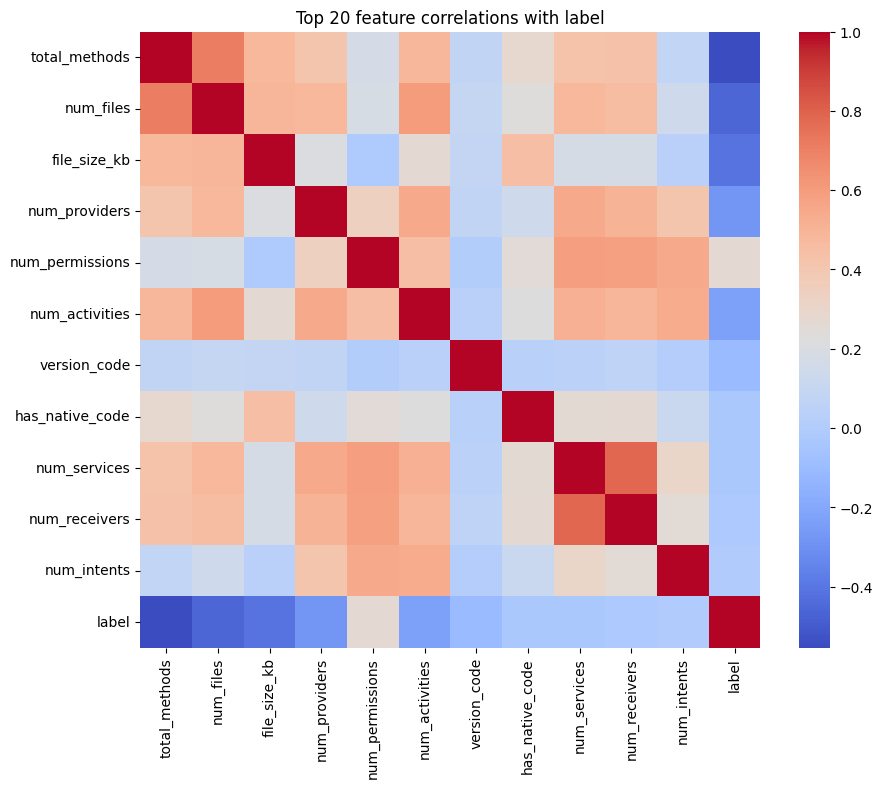

In [37]:


top20 = corr_sorted.head(20).index
corr_matrix = df[top_features + ['label']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Top 20 feature correlations with label")
plt.show()

In [38]:
X_reduced = X[top_features]

In [39]:
print(X.iloc[:,0].head())

0    947.0
1    297.0
2    190.0
3    526.0
4    580.0
Name: num_files, dtype: float64


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2,random_state=42
)

model = RandomForestClassifier(
    n_estimators=200, n_jobs=-1, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9625
Confusion Matrix:
 [[240   8]
 [ 10 222]]
Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       248
           1       0.97      0.96      0.96       232

    accuracy                           0.96       480
   macro avg       0.96      0.96      0.96       480
weighted avg       0.96      0.96      0.96       480



In [41]:
import numpy as np

y_train_shuffled = np.random.permutation(y_train)
model.fit(X_train, y_train_shuffled)
print("Accuracy with shuffled labels:", model.score(X_test, y_test))

Accuracy with shuffled labels: 0.6041666666666666


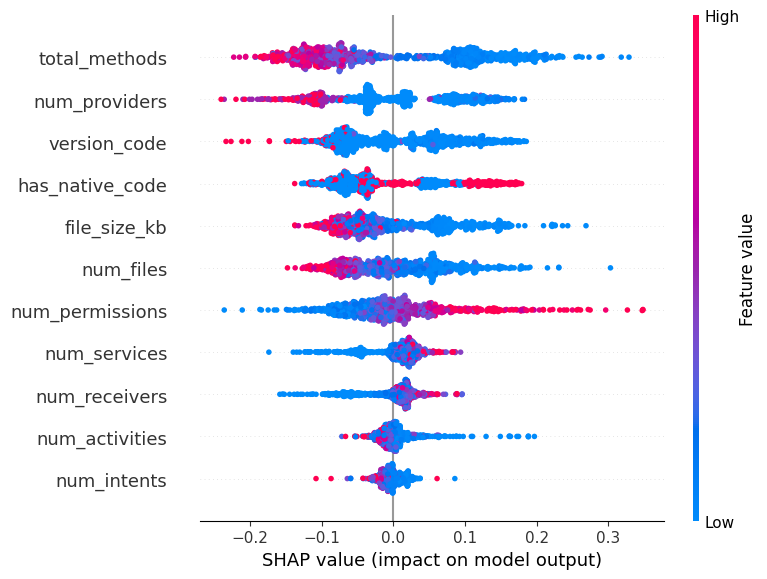

In [42]:

import shap
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# sample only 200 rows
X_sample = X_train.sample(1000)

# train a smaller RF just for SHAP
rf_shap = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_shap.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf_shap)


shap_values = explainer(X_sample)  # only malware class
malicious_shap_values = shap_values [:, :, 1]

shap.summary_plot(malicious_shap_values, X_sample)


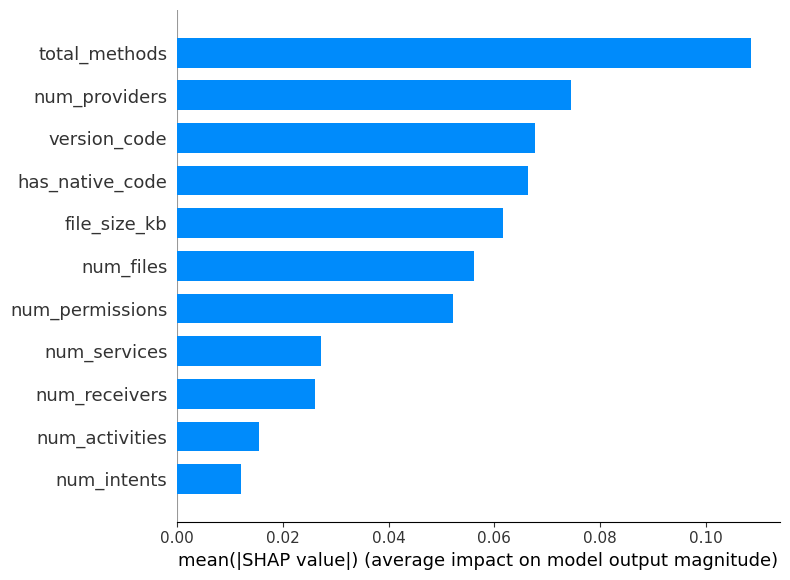

In [43]:
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar")

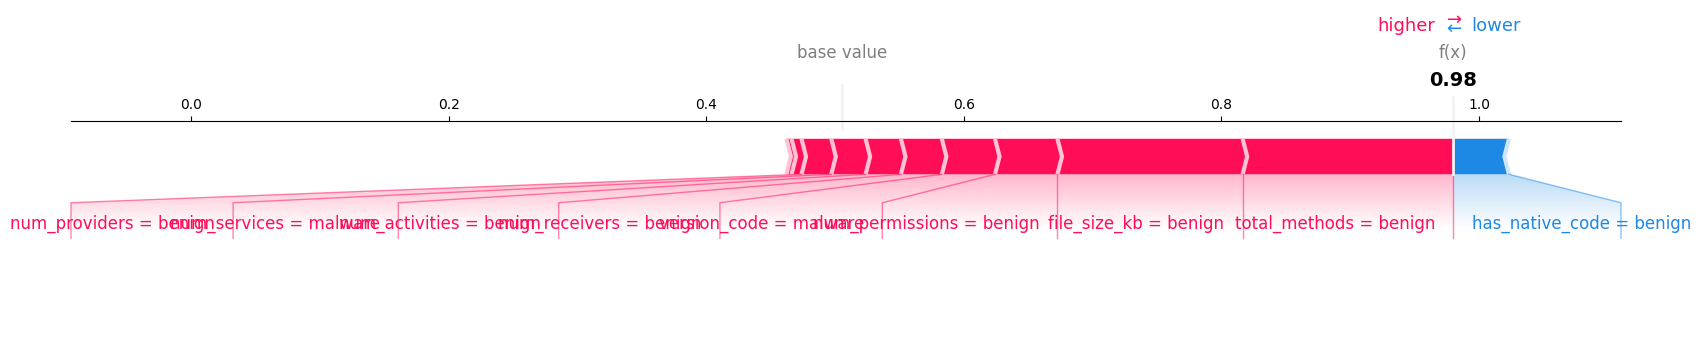

In [44]:
i = 0  # The index of the Android app you want to explain
feature_values = X_sample.iloc[i, :].map(lambda x: 'malware' if x == 1 else 'benign')
# Use .values to get the specific array for the plot
shap.force_plot(
    explainer.expected_value[1],     # The base value for 'Malicious'
    shap_values.values[i, :, 1],    # Add .values here to pass the raw array
    feature_values,        # The actual feature values
    matplotlib=True
)

In [45]:
sample = X_test.iloc[0:70]
pred = model.predict(sample)
# 2. Iterate through the predictions

explainer = shap.TreeExplainer(model)
shap_explanations = explainer(sample, check_additivity=False)

for i, app_pred in enumerate(pred):
    status = "Malware" if app_pred == 1 else "Benign"
    
    # Get the SHAP values for this specific app (class 1: Malicious)
    # We look for the highest positive contributions for Malware
    # and highest negative contributions for Benign
    current_shap_values = shap_explanations.values[i, :, 1]
    feature_names = sample.columns
    
    # Sort features by their impact (absolute SHAP value)
    top_indices = np.argsort(np.abs(current_shap_values))[-3:][::-1]
    
    reasons = []
    for idx in top_indices:
        val = current_shap_values[idx]
        feature_name = feature_names[idx]
        direction = "contributed to Malware risk" if val > 0 else "suggested Benign behavior"
        reasons.append(f"{feature_name} ({direction} by {abs(val):.4f})%")
        

    print(f"App {i}: {status} detected.")
    print(f"   Reasoning: {', '.join(reasons)}\n")

App 0: Benign detected.
   Reasoning: total_methods (contributed to Malware risk by 0.0497)%, num_files (suggested Benign behavior by 0.0390)%, num_permissions (suggested Benign behavior by 0.0246)%

App 1: Malware detected.
   Reasoning: version_code (contributed to Malware risk by 0.0499)%, num_services (contributed to Malware risk by 0.0313)%, num_permissions (suggested Benign behavior by 0.0229)%

App 2: Benign detected.
   Reasoning: num_permissions (suggested Benign behavior by 0.0490)%, num_files (suggested Benign behavior by 0.0439)%, total_methods (contributed to Malware risk by 0.0411)%

App 3: Malware detected.
   Reasoning: num_files (contributed to Malware risk by 0.0305)%, total_methods (suggested Benign behavior by 0.0256)%, num_receivers (suggested Benign behavior by 0.0227)%

App 4: Malware detected.
   Reasoning: file_size_kb (contributed to Malware risk by 0.0389)%, total_methods (contributed to Malware risk by 0.0288)%, num_files (contributed to Malware risk by 0.01